In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# 1. Load Dataset

We are using a phishing email dataset directly from Hugging Face: https://huggingface.co/datasets/zefang-liu/phishing-email-dataset/viewer

In [ ]:
! pip install -q datasets huggingface_hub

In [ ]:
from datasets import load_dataset

dataset = load_dataset("zefang-liu/phishing-email-dataset")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/616 [00:00<?, ?B/s]

Phishing_Email.csv:   0%|          | 0.00/52.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18650 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd

df = pd.DataFrame(dataset['train'])
df.sample(5, random_state=42)

,Unnamed: 0,Email Text,Email Type
14469,14470,"Once upon a time, Harri wrote :> Title page ha...",Safe Email
3014,3014,new books : generative studies we would like t...,Safe Email
16941,16942,new book : japanese linguistics japanese lingu...,Safe Email
14344,14345,renewal notice for your domain name ( s ) dear...,Safe Email
8097,8098,hot stock tip your broker won ' t share now th...,Phishing Email


In [ ]:
print(f"Total rows: {len(df)}")
print(f"Email Text: {type(df['Email Text'][0])}")
print(f"Email Type: {type(df['Email Type'][0])}")

Total rows: 18650
Email Text: <class 'str'>
Email Type: <class 'str'>


* `Unnamed:0`: appears to be a column for rows; int
* `Email Text`: text data of email; string
* `Email Type`: email classification (Safe Email or Phishing Email); string

For better usability, we are removing `Unnamed:0`, rename column names to `text` and `label`, and encode the labels where `0=safe` and `1=phishing`.

In [ ]:
# convert to dataframe
df = pd.DataFrame(dataset['train'])

# extract columns
df = df[["Email Text", "Email Type"]]
df.columns = ["text", "label"] # rename columns

# 0/1 label encoding
df["label"] = df["label"].apply(lambda x: 1 if x == "Phishing Email" else 0)


Total: 18650
Non-phishing: 11322 -- 60.707774798927616
Phishing: 7328 -- 39.292225201072384


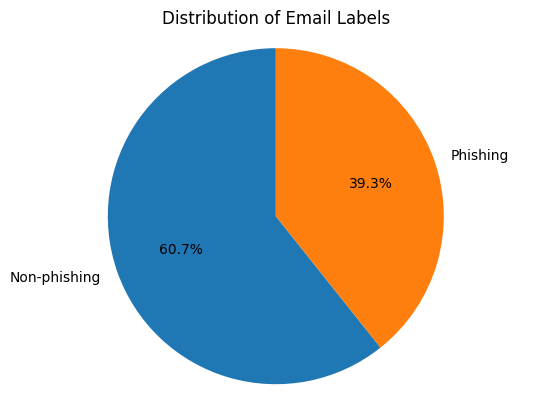

In [ ]:
# check distribution
import matplotlib.pyplot as plt

# count each class
total = len(df)
non_phishing_count = df["label"].value_counts()[0]
phishing_count = df["label"].value_counts()[1]

print(f"Total: {total}")
print(f"Non-phishing: {non_phishing_count} -- {non_phishing_count / total * 100}")
print(f"Phishing: {phishing_count} -- {phishing_count / total * 100}")

labels = ["Non-phishing", "Phishing"]
sizes = [non_phishing_count, phishing_count]

# plot piechart
plt.figure()
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Email Labels")
plt.axis('equal')
plt.show()

About 60% safe emails vs. 40% phishing emails -- not a perfect 50:50 ratio, but relatively evenly split. Good representation of both classes.

# 2. Feature Engineering
We're going to investigate what features distinguish phishing emails from safe emails. The followings are considered:
* phishing keywords
* capitalization ratio
* exclamation count
* URL count

<br>

### Keyword Dictionary
We begin by manually creating a dictionary of keywords that often signal phishing.
* Source:
    * https://expel.com/blog/top-phishing-keywords/
    * https://www.route-fifty.com/cybersecurity/2012/09/the-20-most-common-words-in-phishing-attacks/280956/






In [ ]:
import re
# phishing word dictionary

phishing_keywords = [
    "invoice", "new", "message", "required", "label",
    "file", "request", "action", "document", "verification",
    "copy", "statement", "financial", "notification",
    "transaction", "renewal"
]

def phishing_keyword_features(text):
    text = str(text).lower()

    # tokenize
    tokens = re.findall(r"\b\w+\b", text)

    # track total count of keywords and unique keywords
    keyword_count = sum(token in phishing_keywords for token in tokens)
    unique_keyword_count = len(set(token for token in tokens if token in phishing_keywords))

    # binary value
    has_phishing_keyword = 1 if keyword_count > 0 else 0

    return keyword_count, unique_keyword_count, has_phishing_keyword

### Capitalization Ratio

In [ ]:
def get_capitalization_ratio(text):
    text = str(text)

    letters = sum(1 for char in text if char.isalpha())
    if letters == 0:
        return 0

    capitalized_letter = sum(1 for char in text if char.isupper())
    return (capitalized_letter / letters) if letters > 0 else 0

### Exclamation Count

In [ ]:
def get_exclamation_count(text):
    text = str(text)
    return text.count("!")

### URL Count

In [ ]:
def get_url_count(text):
    text = str(text)
    return len(re.findall(r"http[s]?://\S+|www\.\S+", text))

### Wrapper function
This function applies all feature extraction functions to the input text data and returns a dictionary with the numeric counts.

In [ ]:
def feature_extraction(text):
    text = str(text)

    keyword_count, unique_keyword_count, has_phishing_keyword = phishing_keyword_features(text)
    capitalization_ratio = get_capitalization_ratio(text)
    exclamation_count = get_exclamation_count(text)
    url_count = get_url_count(text)

    return pd.Series({
        "total_phishing_keyword_count": keyword_count,
        "unique_phishing_keyword_count": unique_keyword_count,
        "has_phishing_keyword": has_phishing_keyword,
        "capitalization_ratio": capitalization_ratio,
        "exclamation_count": exclamation_count,
        "url_count": url_count
    })

# 3. Splitting Data & Extract Features

In [ ]:
# 80/10/10 split

from sklearn.model_selection import train_test_split

x = df["text"]
y = df["label"]

# split into train(80) and temp (20)
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y,
    random_state=3,
    test_size=0.2,
    stratify=y)

print(x_train.shape)
print(x_temp.shape)

(14920,)
(3730,)


In [ ]:
x_valid, x_test, y_valid, y_test = train_test_split(
    x_temp, y_temp,
    random_state=3,
    test_size=0.5,
    stratify=y_temp)

print(x_valid.shape)
print(x_test.shape)

(1865,)
(1865,)


In [ ]:
x_train.head()

,text
1120,use Perl Daily Headline MailerNew Perl Mongers...
17586,all prescriptions are dispensed by licensed ph...
8572,msl 50 confirmation thank you for your involve...
15641,re : thank you sevil . we are looking forward ...
4173,out of office autoreply : just to her . . . ic...


In [ ]:
# apply features
x_train_features = x_train.apply(feature_extraction)
x_valid_features = x_valid.apply(feature_extraction)
x_test_features = x_test.apply(feature_extraction)

In [ ]:
feature_df = x_train_features.copy()
feature_df["label"] = y_train.values

In [ ]:
feature_df.groupby("label").mean()

,total_phishing_keyword_count,unique_phishing_keyword_count,has_phishing_keyword,capitalization_ratio,exclamation_count,url_count
label,,,,,,
0,1.657871,0.814970,0.505741,0.021298,0.622764,1.095937
1,1.252303,0.769021,0.443876,0.028569,3.323439,0.286080


In [ ]:
feature_df.groupby("label").describe()

total_phishing_keyword_count                                          \
                             count      mean       std  min  25%  50%  75%   
label                                                                        
0                           9058.0  1.657871  6.116285  0.0  0.0  1.0  2.0   
1                           5862.0  1.252303  2.844903  0.0  0.0  0.0  1.0   

             unique_phishing_keyword_count            ... exclamation_count  \
         max                         count      mean  ...               75%   
label                                                 ...                     
0      245.0                        9058.0  0.814970  ...               0.0   
1       70.0                        5862.0  0.769021  ...               3.0   

             url_count                                                   
         max     count      mean        std  min  25%  50%  75%     max  
label                                                                    
0      179.0    9058.0  1.095937  33.069885  0.0  0.0  0.0  1.0  3133.0  
1      414.0    5862.0  0.286080   1.466410  0.0  0.0  0.0  0.0    52.0  

[2 rows x 48 columns]

# 4. Preprocessing

In [ ]:
def drop_empty_dups(df):
    # remove duplicates and empty values
    df = df.drop_duplicates()
    df = df.dropna()

    # calculate text length
    df["text_length"] = df["text"].astype(str).str.split().str.len()

    # keep only between 21 and 500 words
    df = df[df["text_length"] <= 500]
    df = df[df["text_length"] > 20]

    return df

In [ ]:
import pandas as pd
import re
from collections import defaultdict

def clean_email_text(text):
    """Basic text cleaning for duplicate detection."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove URLs
    text = re.sub(r"[^a-z0-9\s]", " ", text)      # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()      # normalize spaces
    return text

def further_clean(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"\S+@\S+", " <EMAIL> ", text)
    text = re.sub(r"\b\d+\b", " <NUM> ", text)
    text = re.sub(r"\b(?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)\b", " <DATE> ", text)
    text = re.sub(r"\b(account|invoice|order|id|number)\s*\w*", r"\1 <ID>", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [ ]:
# wrapper function
def preprocess_text(text):
    text = clean_email_text(text)
    text = further_clean(text)
    return text

In [ ]:
x_train_clean = x_train.apply(preprocess_text)
x_valid_clean = x_valid.apply(preprocess_text)
x_test_clean = x_test.apply(preprocess_text)

### Data Leakage Check

In [ ]:
train_texts = set(x_train_clean.astype(str))
valid_texts = set(x_valid_clean.astype(str))
test_texts = set(x_test_clean.astype(str))

train_valid_overlap = train_texts & valid_texts
train_test_overlap = train_texts & test_texts
valid_test_overlap = valid_texts & test_texts

print("Exact overlap: train-valid =", len(train_valid_overlap))
print("Exact overlap: train-test =", len(train_test_overlap))
print("Exact overlap: valid-test =", len(valid_test_overlap))

Exact overlap: train-valid = 107
Exact overlap: train-test = 125
Exact overlap: valid-test = 24


# 4. LDA

In [ ]:
# preprocessing for LDA
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt_tab')
nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_lda(text):
    text = str(text).lower()
    tokens = re.findall(r"\b[a-z]+\b", text)
    tokens = [tok for tok in tokens if tok not in stop_words and len(tok) > 2]
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens]
    return tokens

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
x_train_preprocessed_lda = x_train_clean.apply(preprocess_lda)

In [ ]:
try:
  import gensim
except:
  !pip install gensim
  import gensim
from gensim import corpora
from gensim.models import LdaModel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.8 MB/s eta 0:00:00


In [ ]:
train_dictionary = corpora.Dictionary(x_train_preprocessed_lda)
train_corpus = [train_dictionary.doc2bow(text) for text in x_train_preprocessed_lda]

lda_model = LdaModel(
    corpus=train_corpus,
    id2word=train_dictionary,
    num_topics=3,
    random_state=42,
    passes=10
)

In [ ]:
for topic_id, topic_words in lda_model.print_topics():
    print(f"Topic {topic_id}: {topic_words}")

Topic 0: 0.108*"num" + 0.021*"enron" + 0.011*"ect" + 0.008*"company" + 0.006*"date" + 0.005*"hou" + 0.005*"said" + 0.004*"would" + 0.004*"energy" + 0.004*"subject"
Topic 1: 0.077*"num" + 0.011*"language" + 0.008*"university" + 0.005*"paper" + 0.004*"conference" + 0.004*"linguistics" + 0.003*"information" + 0.003*"date" + 0.003*"english" + 0.003*"edu"
Topic 2: 0.083*"num" + 0.005*"email" + 0.005*"com" + 0.005*"list" + 0.005*"get" + 0.004*"one" + 0.004*"mail" + 0.004*"date" + 0.004*"time" + 0.004*"free"


Topic 0 seems to be focused on internal corporate email (i.e., Enron) with words including "enron", "please", "subject", and "send".

Topic 1 seems to have a mixture of mailing list/web-related terms, like "list", "com", "use", and "free". Again, these words do not really represent a coherent topic.

Topic 2 appears to be focused on academic/university-source topic, but this reinforces how the data is source-focused, not phishing semantics.

Lastly, "num" is given the most weight, which means that the placeholder replacement is too strong.

<br>

Based on

In [ ]:
phishing_preprocessed = x_train_clean[y_train == 1].apply(preprocess_lda)
safe_preprocessed = x_train_clean[y_train == 0].apply(preprocess_lda)

In [ ]:
# phishing
phishing_dictionary = corpora.Dictionary(phishing_preprocessed)
phishing_corpus = [phishing_dictionary.doc2bow(text) for text in phishing_preprocessed]
phishing_lda_model = LdaModel(
    corpus=phishing_corpus,
    id2word=phishing_dictionary,
    num_topics=3,
    random_state=42,
    passes=10
)

# safe
safe_dictionary = corpora.Dictionary(safe_preprocessed)
safe_corpus = [safe_dictionary.doc2bow(text) for text in safe_preprocessed]
safe_lda_model = LdaModel(
    corpus=safe_corpus,
    id2word=safe_dictionary,
    num_topics=3,
    random_state=42,
    passes=10
)

In [ ]:
phishing_docs_for_tfidf = [" ".join(doc) for doc in phishing_preprocessed]
safe_docs_for_tfidf = [" ".join(doc) for doc in safe_preprocessed]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

# phishing TF-IDF
phish_vectorizer = TfidfVectorizer()
phish_tfidf = phish_vectorizer.fit_transform(phishing_docs_for_tfidf)
phish_vocab = phish_vectorizer.get_feature_names_out()
phish_scores = phish_tfidf.mean(axis=0).A1
phish_tfidf_scores = dict(zip(phish_vocab, phish_scores))

# safe TF-IDF
safe_vectorizer = TfidfVectorizer()
safe_tfidf = safe_vectorizer.fit_transform(safe_docs_for_tfidf)
safe_vocab = safe_vectorizer.get_feature_names_out()
safe_scores = safe_tfidf.mean(axis=0).A1
safe_tfidf_scores = dict(zip(safe_vocab, safe_scores))

In [ ]:
N = 20
K = phishing_lda_model.num_topics
per_topic = max(1, N // K)

phishing_keywords_lda = {}
phishing_keywords_tfidf = {}
phishing_keywords_combined = {}

for topic_id in range(K):
    topic_words = [word for word, _ in phishing_lda_model.show_topic(topic_id, topn=30)]

    # LDA only
    phishing_keywords_lda[topic_id] = topic_words[:per_topic]

    # TF-IDF re-ranked
    ranked = sorted(topic_words, key=lambda w: phish_tfidf_scores.get(w, 0), reverse=True)
    phishing_keywords_tfidf[topic_id] = ranked[:per_topic]

    # Combined
    combined = topic_words[:per_topic] + ranked[:per_topic]
    phishing_keywords_combined[topic_id] = list(dict.fromkeys(combined))[:per_topic]

print("Phishing LDA keywords:", phishing_keywords_lda)
print("Phishing LDA + TF-IDF keywords:", phishing_keywords_tfidf)
print("Phishing combined keywords:", phishing_keywords_combined)

Phishing LDA keywords: {0: ['num', 'email', 'mail', 'free', 'order', 'address'], 1: ['num', 'company', 'statement', 'date', 'security', 'stock'], 2: ['num', 'http', 'com', 'font', 'pill', 'size']}
Phishing LDA + TF-IDF keywords: {0: ['num', 'click', 'email', 'com', 'free', 'get'], 1: ['num', 'company', 'time', 'business', 'information', 'price'], 2: ['num', 'com', 'http', 'get', 'order', 'offer']}
Phishing combined keywords: {0: ['num', 'email', 'mail', 'free', 'order', 'address'], 1: ['num', 'company', 'statement', 'date', 'security', 'stock'], 2: ['num', 'http', 'com', 'font', 'pill', 'size']}


In [ ]:
N = 20
K = safe_lda_model.num_topics
per_topic = max(1, N // K)

safe_keywords_lda = {}
safe_keywords_tfidf = {}
safe_keywords_combined = {}

for topic_id in range(K):
    topic_words = [word for word, _ in safe_lda_model.show_topic(topic_id, topn=30)]

    safe_keywords_lda[topic_id] = topic_words[:per_topic]

    ranked = sorted(topic_words, key=lambda w: safe_tfidf_scores.get(w, 0), reverse=True)
    safe_keywords_tfidf[topic_id] = ranked[:per_topic]

    combined = topic_words[:per_topic] + ranked[:per_topic]
    safe_keywords_combined[topic_id] = list(dict.fromkeys(combined))[:per_topic]

print("Safe LDA keywords:", safe_keywords_lda)
print("Safe LDA + TF-IDF keywords:", safe_keywords_tfidf)
print("Safe combined keywords:", safe_keywords_combined)

Safe LDA keywords: {0: ['num', 'language', 'university', 'paper', 'conference', 'linguistics'], 1: ['num', 'enron', 'ect', 'company', 'hou', 'date'], 2: ['num', 'list', 'one', 'date', 'get', 'user']}
Safe LDA + TF-IDF keywords: {0: ['num', 'date', 'language', 'please', 'one', 'university'], 1: ['num', 'enron', 'ect', 'date', 'please', 'would'], 2: ['num', 'date', 'list', 'linux', 'would', 'com']}
Safe combined keywords: {0: ['num', 'language', 'university', 'paper', 'conference', 'linguistics'], 1: ['num', 'enron', 'ect', 'company', 'hou', 'date'], 2: ['num', 'list', 'one', 'date', 'get', 'user']}


In [ ]:
phish_combined_words = []
for words in phishing_keywords_combined.values():
    phish_combined_words.extend(words)

safe_combined_words = []
for words in safe_keywords_combined.values():
    safe_combined_words.extend(words)

phish_freq = Counter(phish_combined_words)
safe_freq = Counter(safe_combined_words)

In [ ]:
!pip install WordCloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

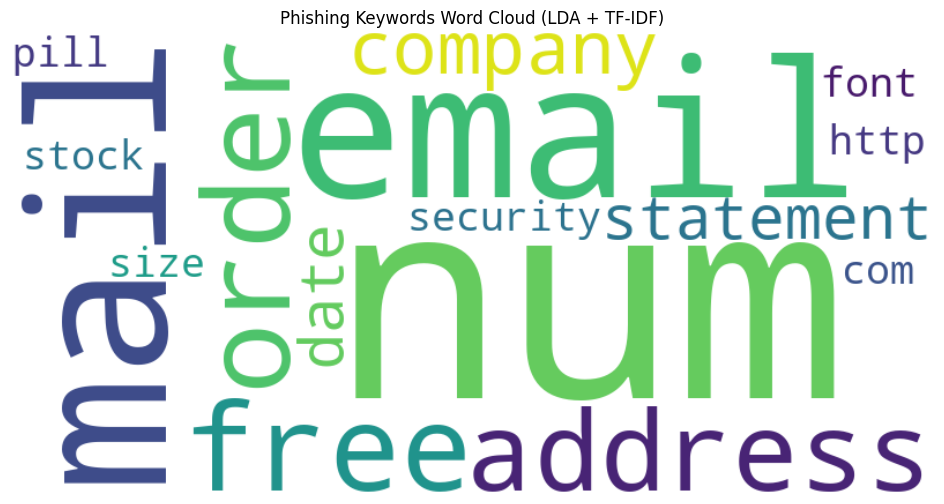

In [ ]:
phish_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(phish_freq)

plt.figure(figsize=(12, 6))
plt.imshow(phish_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Phishing Keywords Word Cloud (LDA + TF-IDF)")
plt.show()

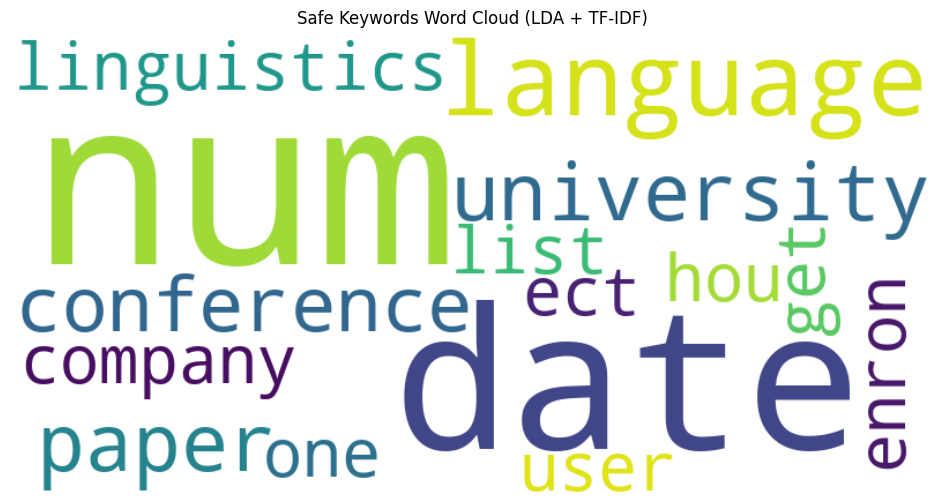

In [ ]:
safe_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(safe_freq)

plt.figure(figsize=(12, 6))
plt.imshow(safe_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Safe Keywords Word Cloud (LDA + TF-IDF)")
plt.show()

# 5. Modeling

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
x_train_tfidf_processed = tfidf.fit_transform(x_train_clean)
x_valid_tfidf_processed = tfidf.transform(x_valid_clean)

In [ ]:
# scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_features_scaled = scaler.fit_transform(x_train_features)
x_valid_features_scaled = scaler.transform(x_valid_features)
x_test_features_scaled = scaler.transform(x_test_features)

In [ ]:
# combine with preprocessed tfidf
from scipy.sparse import hstack, csr_matrix

x_train_combined = hstack([x_train_tfidf_processed, csr_matrix(x_train_features_scaled)])
x_valid_combined = hstack([x_valid_tfidf_processed, csr_matrix(x_valid_features_scaled)])

In [ ]:
# training logistic regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(x_train_combined, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_valid_pred = lr_model.predict(x_valid_combined)
y_valid_prob = lr_model.predict_proba(x_valid_combined)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# evaluate
print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(y_valid, y_valid_pred))

print(confusion_matrix(y_valid, y_valid_pred))

Accuracy: 0.9581769436997319
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1132
           1       0.93      0.97      0.95       733

    accuracy                           0.96      1865
   macro avg       0.95      0.96      0.96      1865
weighted avg       0.96      0.96      0.96      1865

[[1079   53]
 [  25  708]]


# 6. Comparison without Features

We're going to compare how the model performs with preprocessed data *without* feature sets.

In [ ]:
# without prepreprocessing
lr_no_features = LogisticRegression(max_iter=1000, random_state=42)
lr_no_features.fit(x_train_tfidf_processed, y_train)

y_valid_pred_no_features = lr_no_features.predict(x_valid_tfidf_processed)
y_valid_prob_no_features = lr_no_features.predict_proba(x_valid_tfidf_processed)[:, 1]

In [ ]:
# evaluate

print("Accuracy:", accuracy_score(y_valid, y_valid_pred_no_features))

print(classification_report(y_valid, y_valid_pred_no_features))

print(confusion_matrix(y_valid, y_valid_pred))

Accuracy: 0.9576407506702412
              precision    recall  f1-score   support

           0       0.98      0.95      0.96      1132
           1       0.93      0.96      0.95       733

    accuracy                           0.96      1865
   macro avg       0.95      0.96      0.96      1865
weighted avg       0.96      0.96      0.96      1865

[[1079   53]
 [  25  708]]


We can see that the model performs slightly better with the handcrafted features, but the difference is not significant.

# 7. Downloading the Model


In [ ]:
import joblib

trained_pipeline = {
    "tfidf": tfidf,
    "scaler": scaler,
    "model": lr_model
}

joblib.dump(trained_pipeline, "tfidf_lr_phishing.pkl")

['tfidf_lr_phishing.pkl']